# White Premium and SB Calendar Spreads — Reference

A tutorial walkthrough of the pure functions in [make_charts.py](make_charts.py) and [spread_chart.py](spread_chart.py).

This notebook **imports** the functions, it does not redefine them — so if the source files change, restart the kernel and re-run.

Each section: a worked example, the current output, an explanation of what's being computed, and the relevant chart. The **gotchas** are the parts that bit me (or will) so they're called out explicitly.

Run order assumes the working directory is the repo root (`sugar/`).

## Setup

In [26]:
import make_charts as mc
import spread_chart as sc
from IPython.display import Image, display
import pandas as pd

pd.set_option("display.max_rows", 8)
pd.set_option("display.precision", 2)

---
## 1. `white_premium(sb, qw)` — the per-row math

Returns `qw - sb * 22.0462`. Vectorises across scalars or Series.

**What it computes:** the white-sugar premium expressed in $/tonne, by converting the raw price (SB, in cents/lb) into the same unit as the whites price (QW, in $/tonne) and taking the difference.

**Gotcha — units.** The 22.0462 factor bakes in `(1 lb / 0.453592 kg) × (1000 kg / 1 t) ÷ 100`. SB is *cents per pound*; QW is *dollars per tonne*. Mixing units (or skipping the divide-by-100) silently produces numbers that look plausible but are an order of magnitude wrong.

In [27]:
# Scalar form — sanity check the math
sb = 17.5   # cents/lb
qw = 510.0  # $/tonne
wp = mc.white_premium(sb, qw)
print(f"SB={sb} c/lb, QW=${qw}/t  ->  WP = ${wp:.2f}/t")

SB=17.5 c/lb, QW=$510.0/t  ->  WP = $124.19/t


In [28]:
# Vectorised — applied row-by-row inside white_premium_history
df = mc.white_premium_history(years=5)
df.tail()

,date,price_sb,price_qw,wp
2705,2026-05-15,14.78,438.8,112.96
2706,2026-05-18,14.71,436.3,112.00
2707,2026-05-19,15.04,441.5,109.93
2708,2026-05-20,14.76,441.6,116.20
2709,2026-05-21,14.84,445.3,118.13


---
## 2. `white_premium_stats(years, anchor)` — windowed stats + dWP decomposition

Returns a pure dict: current WP, percentile rank within the window, min/max/mean/median/IQR, and a decomposition of the WP change since an anchor date into a raws leg (`-dSB × 22.0462`) and a whites leg (`dQW`). The two legs sum to `dWP` by construction.

**What it computes:** how the white premium has moved since a chosen reference point, and how much of that move is attributable to each underlying leg.

**Gotcha — anchor-dependence.** The decomposition's answer changes with the anchor. `anchor="window_low"` measures the move off the deepest WP in the window (a multi-year structural read). `anchor="recent_low"` measures the move off the most recent confirmed local dip (a near-term tactical read). They will often disagree about which leg is doing the work.

In [29]:
window_low = mc.white_premium_stats(years=5, anchor="window_low")
recent_low = mc.white_premium_stats(years=5, anchor="recent_low")

print(f"current WP:  ${window_low['current']:.1f}/t   ({window_low['percentile']:.0f}th pct of 5y window)")
print(f"5y range:    ${window_low['min']:.1f}  ..  ${window_low['max']:.1f}")
print(f"5y mean:     ${window_low['mean']:.1f}    median ${window_low['median']:.1f}    IQR ${window_low['q1']:.1f}-${window_low['q3']:.1f}")
print()
for s in [window_low, recent_low]:
    print(f"anchor={s['anchor_kind']:<12s}  date {s['anchor_date']:%Y-%m-%d}  @ ${s['anchor_wp']:6.1f}/t")
    print(f"  dWP:        ${s['delta_wp']:+7.1f}/t")
    print(f"    raws:     ${s['raws_leg']:+7.1f}/t")
    print(f"    whites:   ${s['whites_leg']:+7.1f}/t")

current WP:  $118.1/t   (58th pct of 5y window)
5y range:    $37.0  ..  $169.9
5y mean:     $111.8    median $111.7    IQR $95.7-$134.0

anchor=window_low    date 2021-08-10  @ $  37.0/t
  dWP:        $  +81.2/t
    raws:     $ +104.1/t
    whites:   $  -22.9/t
anchor=recent_low    date 2026-04-09  @ $ 105.5/t
  dWP:        $  +12.6/t
    raws:     $  -15.9/t
    whites:   $  +28.5/t


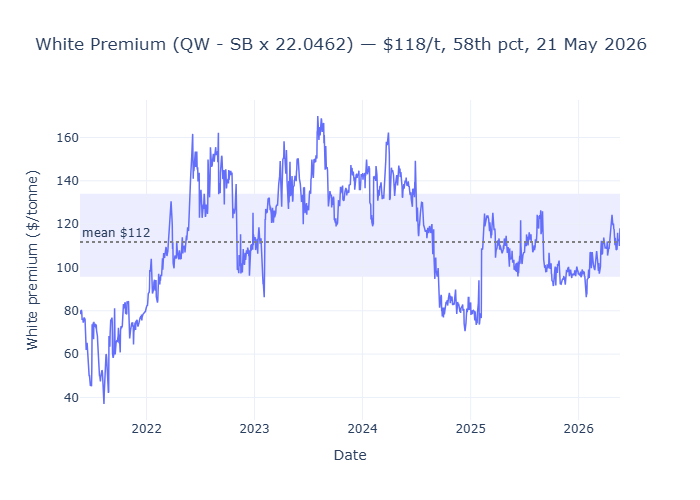

In [30]:
display(Image("charts/white_premium_5y.png"))

Read the chart: the dotted line is the 5y mean, the shaded band is the IQR (q1-q3), and the title carries the current value and percentile. The chart itself is anchor-agnostic — anchors only affect the decomposition numbers above.

### Settled verdict (21 May 2026)

Loaded verbatim from [wp_verdict.md](wp_verdict.md) so the notebook, the chart title, and `white_premium_stats` agree by construction. The check cell below flags any drift from the settled numbers instead of editing the prose.

In [31]:
from pathlib import Path
from IPython.display import Markdown, display
display(Markdown(Path("wp_verdict.md").read_text(encoding="utf-8")))

# White premium verdict — 21 May 2026

WP sits at ~$118/t (QW 445 − SB 14.84×22.0462). On the 5-year window (range $37–170, mean/median ~$112, IQR $96–134) that's the ~58th percentile — middling, not elevated. On level alone it's unremarkable; the tell is the composition, which differs by horizon, so the anchor must be stated:

Structural (since the Aug-2021 window low, ~$37): the +$81 widening is raws-led — raws leg +$104 (SB collapsed), whites leg −$23 (QW also fell). The multi-year wide premium is a cheap-raws story (surplus / record Brazil crush dragging ICE 11 to multi-year lows), not refining tightness.

Near-term (since the Jan-2026 recent low): the +$32 uptick is whites-led — whites firmed ~$32, raws roughly flat. Coherent with reduced white availability (refining/white-export constraints, reinforced by India's 13 May ban prohibiting white as well as raw exports).

Net: don't read $118 as "refining is tight" — structurally it's cheap raws, not strong whites; but the near-term direction is genuine whites firming, and a continued whites-led move (QW up while SB holds) would signal actual white tightness building. Window and anchor stated because both change the answer: a ~10yr window puts the same $118 nearer the 78th percentile, and a different anchor flips the attribution.


In [32]:
# Sanity check: settled verdict numbers vs what white_premium_stats produces NOW.
# Tolerances reflect the '~' rounding in the verdict text.
ws = mc.white_premium_stats(years=5, anchor="window_low")
rs = mc.white_premium_stats(years=5, anchor="recent_low")

checks = [
    ("current WP",         ws["current"],       118.0, 0.5),
    ("5y mean",            ws["mean"],          112.0, 1.0),
    ("5y median",          ws["median"],        112.0, 1.0),
    ("5y min",             ws["min"],            37.0, 1.0),
    ("5y max",             ws["max"],           170.0, 1.0),
    ("5y IQR low (q1)",    ws["q1"],             96.0, 1.0),
    ("5y IQR high (q3)",   ws["q3"],            134.0, 1.0),
    ("percentile",         ws["percentile"],     58.0, 1.0),
    ("window-low dWP",     ws["delta_wp"],       81.0, 1.0),
    ("window-low raws",    ws["raws_leg"],      104.0, 1.0),
    ("window-low whites",  ws["whites_leg"],    -23.0, 1.0),
    ("recent-low dWP",     rs["delta_wp"],       32.0, 1.0),
    ("recent-low raws",    rs["raws_leg"],        0.0, 5.0),
    ("recent-low whites",  rs["whites_leg"],     32.0, 1.0),
]

header = f"{'claim':<22s} {'verdict':>9s} {'computed':>10s} {'diff':>7s}  status"
print(header)
mismatches = []
for name, computed, claim, tol in checks:
    diff = computed - claim
    ok = abs(diff) <= tol
    status = 'OK' if ok else 'MISMATCH'
    print(f"{name:<22s} {claim:>+9.2f} {computed:>+10.2f} {diff:>+7.2f}  {status}")
    if not ok:
        mismatches.append((name, claim, computed, tol))

print()
if mismatches:
    print(f"{len(mismatches)} mismatch(es) vs the settled verdict:")
    for name, claim, comp, tol in mismatches:
        print(f"  - {name}: verdict ~{claim:+.1f}, computed {comp:+.2f}, tol +/-{tol}")
    print('Prose in wp_verdict.md NOT edited. Surface this to the analyst.')
else:
    print('All checks within tolerance: verdict, stats, and chart title agree.')

claim                    verdict   computed    diff  status
current WP               +118.00    +118.13   +0.13  OK
5y mean                  +112.00    +111.80   -0.20  OK
5y median                +112.00    +111.66   -0.34  OK
5y min                    +37.00     +36.98   -0.02  OK
5y max                   +170.00    +169.91   -0.09  OK
5y IQR low (q1)           +96.00     +95.67   -0.33  OK
5y IQR high (q3)         +134.00    +133.99   -0.01  OK
percentile                +58.00     +57.55   -0.45  OK
window-low dWP            +81.00     +81.16   +0.16  OK
window-low raws          +104.00    +104.06   +0.06  OK
window-low whites         -23.00     -22.90   +0.10  OK
recent-low dWP            +32.00     +12.63  -19.37  MISMATCH
recent-low raws            +0.00     -15.87  -15.87  MISMATCH
recent-low whites         +32.00     +28.50   -3.50  MISMATCH

3 mismatch(es) vs the settled verdict:
  - recent-low dWP: verdict ~+32.0, computed +12.63, tol +/-1.0
  - recent-low raws: verdict ~+0.0

---
## 3. `load_spread_pair(sheet)` — the calendar-spread building block

Reads a 4-column sheet `[Date, nearby, Date, deferred]` from `data/nv_spread_frozen.xlsx`, merges the two legs on date, and returns `[date, nearby, deferred, spread]` with `spread = deferred - nearby`. Positive = contango.

**What it computes:** the time series of a single calendar spread, properly aligned to dates where both legs traded.

**Gotcha — inner merge on date.** Any day where only one of the two legs has a print is dropped from the result. For thin/illiquid contracts this can silently shrink the series. If a season looks suspiciously short, the cause is usually one leg trading days the other didn't.

In [33]:
nv26 = sc.load_spread_pair("NV26")
print(f"{len(nv26)} merged rows from {nv26['date'].min():%Y-%m-%d} to {nv26['date'].max():%Y-%m-%d}")
nv26.tail()

626 merged rows from 2023-11-02 to 2026-05-22


,date,nearby,deferred,spread
621,2026-05-18,14.71,15.20,0.49
622,2026-05-19,15.04,15.48,0.44
623,2026-05-20,14.76,15.25,0.49
624,2026-05-21,14.90,15.39,0.49
625,2026-05-22,14.68,15.14,0.46


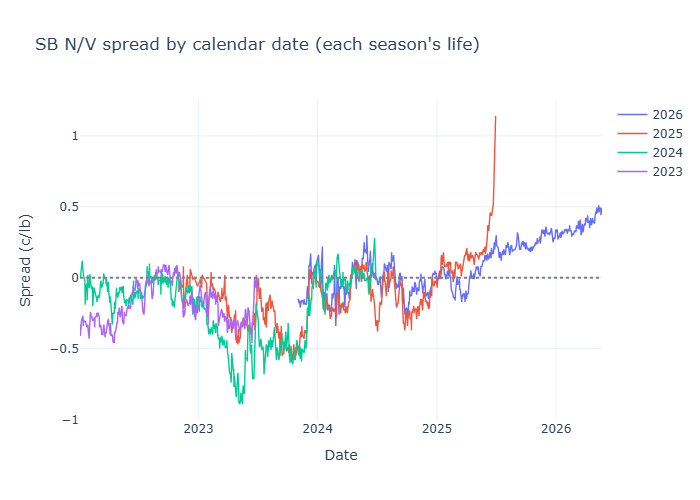

In [34]:
display(Image("charts/sb_nv_calendar.png"))

---
## 4. `season_spread(sheet, expiry_year, nearby_expiry=(6, 30))` — aligned by days-to-expiry

Wraps `load_spread_pair` and adds a `days_to_exp` column counting days from each row's date back to the nearby contract's expiry. This is what makes the seasonal overlay chart work — every season is plotted against the same x-axis ("days to nearby expiry") instead of calendar date.

**What it computes:** the same spread as `load_spread_pair`, plus a time-to-expiry coordinate so seasons stack on top of each other.

**Gotcha — generic function, fixed-month default.** The default `nearby_expiry=(6, 30)` is the JULY (N) contract's last trading date. For any non-N nearby contract (V, H, K, ...) the default is wrong and you'll get bogus `days_to_exp` values without any warning. If you pass `sheet="VH_HK27"`, you must also pass the right `nearby_expiry`. This is the cleanest example in the codebase of a function that's generic in name but fixed-month in behaviour.

In [35]:
# Correct use: NV (Jul/Oct) season — default nearby_expiry is right
nv26_season = sc.season_spread("NV26", 2026)
print("NV26 with default (6,30) nearby expiry:")
nv26_season[["date", "nearby", "deferred", "spread", "days_to_exp"]].tail()

NV26 with default (6,30) nearby expiry:


,date,nearby,deferred,spread,days_to_exp
621,2026-05-18,14.71,15.20,0.49,43
622,2026-05-19,15.04,15.48,0.44,42
623,2026-05-20,14.76,15.25,0.49,41
624,2026-05-21,14.90,15.39,0.49,40
625,2026-05-22,14.68,15.14,0.46,39


In [36]:
# WRONG use: V/H spread with default (6,30) — days_to_exp would refer to July, not October.
# The correct nearby_expiry for V (October) is ~(9, 30).
wrong = sc.season_spread("VH_HK27", 2026)               # silently bogus days_to_exp
right = sc.season_spread("VH_HK27", 2026, nearby_expiry=(9, 30))
print("VH_HK27 last row, days_to_exp:")
print(f"  default (6,30) -> {wrong['days_to_exp'].iloc[-1]:>4d}  (wrong — counts to July)")
print(f"  explicit (9,30) -> {right['days_to_exp'].iloc[-1]:>4d}  (correct — counts to October)")

VH_HK27 last row, days_to_exp:
  default (6,30) ->   39  (wrong — counts to July)
  explicit (9,30) ->  131  (correct — counts to October)


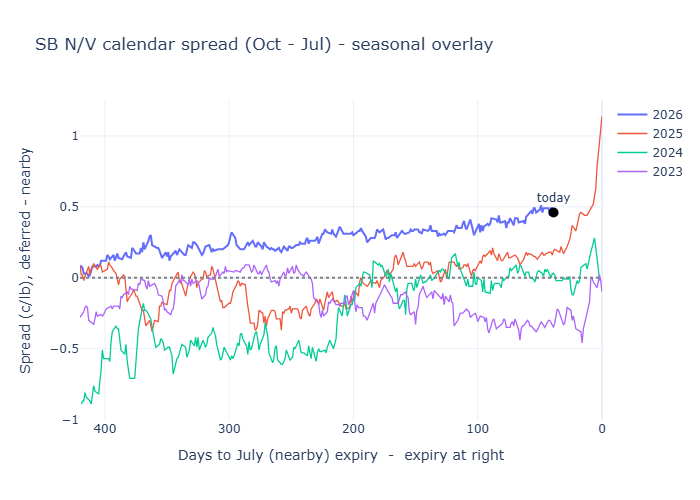

In [37]:
display(Image("charts/sb_nv_seasonal_overlay.png"))

Read the chart: x-axis is reversed so expiry sits on the right; each line is one season's N/V history aligned by days-to-July-expiry. The black dot is where today's NV26 sits relative to prior seasons.

---
## 5. `current_curve()` — today's near-term calendar curve

Returns two dicts: `legs` (the latest prices of N26, V26, H27, K27) and `spreads` (the three near-term calendar spreads computed from them: N/V, V/H, H/K). All in cents/lb.

**What it computes:** a one-shot snapshot of the near-end of the SB forward curve, decomposed into adjacent calendar spreads. Useful for spotting which part of the curve is the kink.

**Gotcha — hardcoded sheet years.** The function references sheets `"NV26"` and `"VH_HK27"` literally. When the calendar rolls past the K27 expiry (May 2027), the legs become stale and the function needs the sheet names updated. There is no automatic rollover.

In [38]:
spreads, legs = sc.current_curve()
print("Latest legs (c/lb):")
for k, v in legs.items():
    print(f"  {k:<4s}  {v:6.2f}")
print()
print("Calendar spreads (c/lb, deferred - nearby):")
for k, v in spreads.items():
    print(f"  {k:<22s}  {v:+6.2f}")

Latest legs (c/lb):
  N26    14.68
  V26    15.14
  H27    16.01
  K27    15.81

Calendar spreads (c/lb, deferred - nearby):
  N/V (Jul26-Oct26)        +0.46
  V/H (Oct26-Mar27)        +0.87
  H/K (Mar27-May27)        -0.20


---
## Summary — Dash port priorities

The data-layer functions above are all pure given the frozen xlsx files, so they lift into a Dash callback as-is. The two friction points to address before the port:

1. `season_spread`'s `nearby_expiry=(6, 30)` default — pass it explicitly or derive it from the sheet name.
2. `current_curve`'s hardcoded sheet names — derive the near-term cycle from the latest available sheets so it rolls forward automatically.

Everything else is cosmetic.